# ProtT5 Differential Phosphorylation Classifier: EGFR-Mutant LUAD vs Null Sites (Clean Pipeline)

This notebook mirrors the Ankh and ESM2 pipelines but uses **ProtT5-XL-UniRef50 (1024-dim)** per-residue embeddings.

## Dataset
- **EGFR-enriched** (`EGFR_enriched_sites_with_pep_location_and_windows.csv`): phosphosites significantly upregulated in EGFR-mutant LUAD.
- **Null sites** (`null_sites_with_pep_location_and_windows.csv`): non-differential phosphosites.

## What this notebook does
1. **Setup** — imports, paths, reproducibility seeds.
2. **Load data** — read both CSVs, inspect and validate.
3. **EDA** — class distribution, logFC / significance distributions, central residue composition.
4. **ProtT5 embedding** — embed full protein sequences with `Rostlab/prot_t5_xl_uniref50` (1024-dim); cache to disk.
5. **Window extraction** — slice 15-residue context windows centred on each phosphosite.
6. **Train / test split** — stratified 80/20 split.
7. **Model training** — four architectures: Max-Pool MLP, Attention-Pool MLP, Center-Only MLP, Hybrid (Center + Attention).
8. **Evaluation** — ROC-AUC, PR-AUC, confusion matrices, classification reports.
9. **Visualisation** — ROC / PR curves, confusion-matrix heat maps, PCA / t-SNE.
10. **Summary & report** — save all plots + self-contained HTML report to `results_phospho_EGFR_ProtT5/`.

> **Kernel:** same `esm2_env` kernel — `transformers` and `sentencepiece` are already installed.
> **Model note:** ProtT5-XL is ~3 B parameters; BATCH_SIZE=1 to avoid OOM.

## Cell 1 — Imports & Global Settings

In [1]:
from pathlib import Path
import hashlib
import random
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from transformers import T5Tokenizer, T5EncoderModel
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device  : {device}")
import transformers
print(f"transformers    : {transformers.__version__}")
print(f"NumPy version   : {np.__version__}")
print(f"Pandas version  : {pd.__version__}")

/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/protT5_env/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/protT5_env/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


PyTorch device  : cuda
transformers    : 4.57.6
NumPy version   : 2.0.2
Pandas version  : 2.3.3


## Cell 2 — Paths & Results Directory

In [2]:
PROJECT_DIR = Path.cwd()                           # Claude_Agent_Phospho_EGFR_NAT_LUAD/
DATA_DIR    = PROJECT_DIR.parent                   # EGFR_UP_vs_Null_sites/
RESULTS_DIR = PROJECT_DIR / "results_phospho_EGFR_ProtT5"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EGFR_FILE   = DATA_DIR / "EGFR_enriched_sites_with_pep_location_and_windows.csv"
NULL_FILE   = DATA_DIR / "null_sites_with_pep_location_and_windows.csv"
EMBED_CACHE = PROJECT_DIR / "prott5_window_embeddings.npz"

print(f"Project dir  : {PROJECT_DIR}")
print(f"Data dir     : {DATA_DIR}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"EGFR file    : {EGFR_FILE.exists()} — {EGFR_FILE}")
print(f"Null file    : {NULL_FILE.exists()} — {NULL_FILE}")
print(f"Embed cache  : {EMBED_CACHE.exists()} — {EMBED_CACHE}")

Project dir  : /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD
Data dir     : /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites
Results dir  : /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR_ProtT5
EGFR file    : True — /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/EGFR_enriched_sites_with_pep_location_and_windows.csv
Null file    : True — /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/null_sites_with_pep_location_and_windows.csv
Embed cache  : False — /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/prott5_window_embeddings.npz


## Cell 3 — Load & Validate Data

In [3]:
egfr_df = pd.read_csv(EGFR_FILE)
null_df  = pd.read_csv(NULL_FILE)

print(f"EGFR-enriched shape : {egfr_df.shape}")
print(f"Null sites shape    : {null_df.shape}")

assert list(egfr_df.columns) == list(null_df.columns), "Column mismatch!"
print("Columns match.")

required = ["Sequence", "win15_start", "win15_end", "win15_seq",
            "logFC", "adj.P.Val", "phosphosite", "Gene Names"]
for col in required:
    assert col in egfr_df.columns, f"Missing column: {col}"
print("All required columns present.")

egfr_clean = egfr_df.dropna(subset=["win15_start", "win15_end", "win15_seq", "Sequence"]).copy()
null_clean  = null_df.dropna(subset=["win15_start", "win15_end", "win15_seq", "Sequence"]).copy()

egfr_clean = egfr_clean[(egfr_clean["win15_end"] - egfr_clean["win15_start"] + 1) == 15]
null_clean  = null_clean[(null_clean["win15_end"]  - null_clean["win15_start"]  + 1) == 15]

print(f"\nAfter cleaning:")
print(f"  EGFR-enriched : {len(egfr_clean)} sites")
print(f"  Null sites    : {len(null_clean)} sites")

print(f"\nEGFR logFC range    : {egfr_clean['logFC'].min():.3f} — {egfr_clean['logFC'].max():.3f}")
print(f"Null logFC range    : {null_clean['logFC'].min():.3f} — {null_clean['logFC'].max():.3f}")
print(f"\nEGFR adj.P.Val range: {egfr_clean['adj.P.Val'].min():.2e} — {egfr_clean['adj.P.Val'].max():.3f}")
print(f"Null adj.P.Val range: {null_clean['adj.P.Val'].min():.3f} — {null_clean['adj.P.Val'].max():.3f}")

EGFR-enriched shape : (2189, 52)
Null sites shape    : (1844, 52)
Columns match.
All required columns present.

After cleaning:
  EGFR-enriched : 2102 sites
  Null sites    : 1765 sites

EGFR logFC range    : 0.150 — 3.228
Null logFC range    : -0.206 — 0.159

EGFR adj.P.Val range: 1.57e-150 — 0.145
Null adj.P.Val range: 0.250 — 1.000


In [4]:
SHOW_COLS = ["phosphosite", "Gene Names", "logFC", "adj.P.Val", "win15_seq", "pep_start", "pep_end"]
print("=== EGFR-enriched sites (top 5) ===")
display(egfr_clean[SHOW_COLS].head())
print("\n=== Null sites (top 5) ===")
display(null_clean[SHOW_COLS].head())

=== EGFR-enriched sites (top 5) ===


,phosphosite,Gene Names,logFC,adj.P.Val,win15_seq,pep_start,pep_end
0,ENSP00000224237.5_5_11_1_1_S10,VIM,3.228115,3.152117e-93,TRSVSSSSYRRMFGG,4.0,12.0
1,ENSP00000233575.2_407_409_1_1_S409,SNX17 KIAA0064,2.888015,1.463639e-68,GTLRRSDSQQAVKSP,406.0,413.0
2,ENSP00000268933.3_179_192_1_1_S182,EPN3,2.834027,1.225043e-68,DYSRSRGSPSSYNSS,178.0,193.0
3,ENSP00000389377.2_256_261_1_1_S261,NFATC1 NFAT2 NFATC,2.572788,1.011128e-108,ARSSRPASPCNKRKY,255.0,264.0
4,ENSP00000328023.5_142_142_1_1_S142,SRPRA SRPR,2.431169,8.991638e-53,TMKKFEDSEKAKKPV,137.0,143.0



=== Null sites (top 5) ===


,phosphosite,Gene Names,logFC,adj.P.Val,win15_seq,pep_start,pep_end
0,ENSP00000299601.5_212_220_1_1_S220,LEO1 RDL,0.053766,0.722254,DDERPVASDNDDEKQ,209.0,225.0
1,ENSP00000294383.5_1129_1146_1_1_S1141,USP24 KIAA1057,0.018113,0.835047,SSSQSSKSPSLSSKQ,1128.0,1146.0
2,ENSP00000256474.3_65_72_1_1_S68,VHL,-0.057343,0.340816,PVLRSVNSREPSQVI,64.0,78.0
3,ENSP00000347375.3_411_439_1_1_S435,TBC1D9B KIAA0676,0.045120,0.468083,EQPASPASPLSSRQS,409.0,439.0
4,ENSP00000385000.3_97_100_1_1_T97,KIF2A KIF2 KNS2,-0.039405,0.698465,KIVKNRRTVASIKND,93.0,101.0


## Cell 4 — Exploratory Data Analysis (EDA)

/tmp/ipykernel_1013827/1351595933.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x="Class", y="Count",


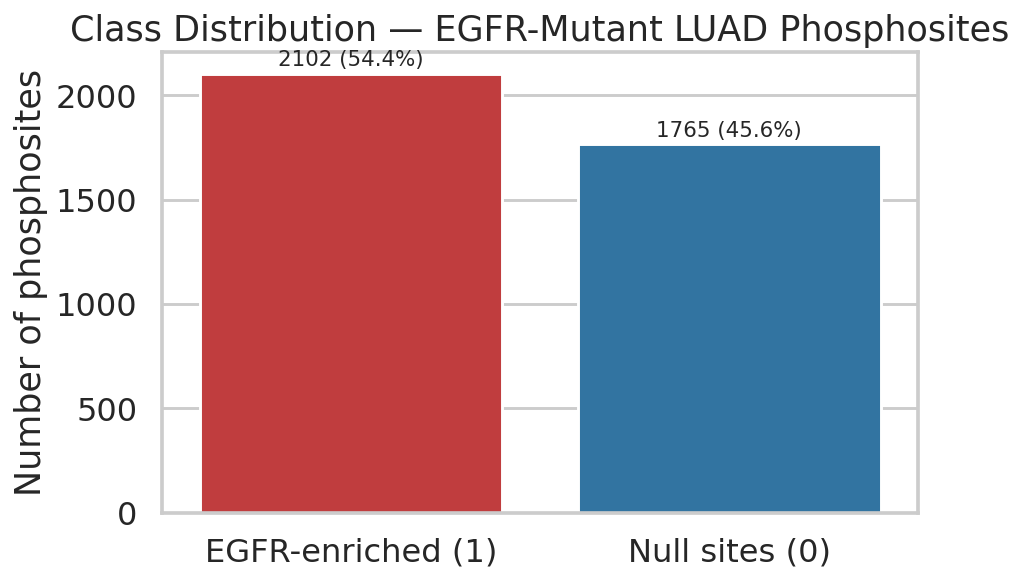

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR_ProtT5/01_class_distribution.png


In [5]:
class_counts = pd.DataFrame({
    "Class":  ["EGFR-enriched (1)", "Null sites (0)"],
    "Count": [len(egfr_clean), len(null_clean)]
})
class_counts["Fraction"] = class_counts["Count"] / class_counts["Count"].sum()

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=class_counts, x="Class", y="Count",
            palette=["#d62728", "#1f77b4"], ax=ax)
ax.set_title("Class Distribution — EGFR-Mutant LUAD Phosphosites")
ax.set_xlabel("")
ax.set_ylabel("Number of phosphosites")
for i, row in class_counts.iterrows():
    ax.text(i, row["Count"] * 1.01,
            f"{row['Count']} ({row['Fraction']:.1%})",
            ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '01_class_distribution.png'}")

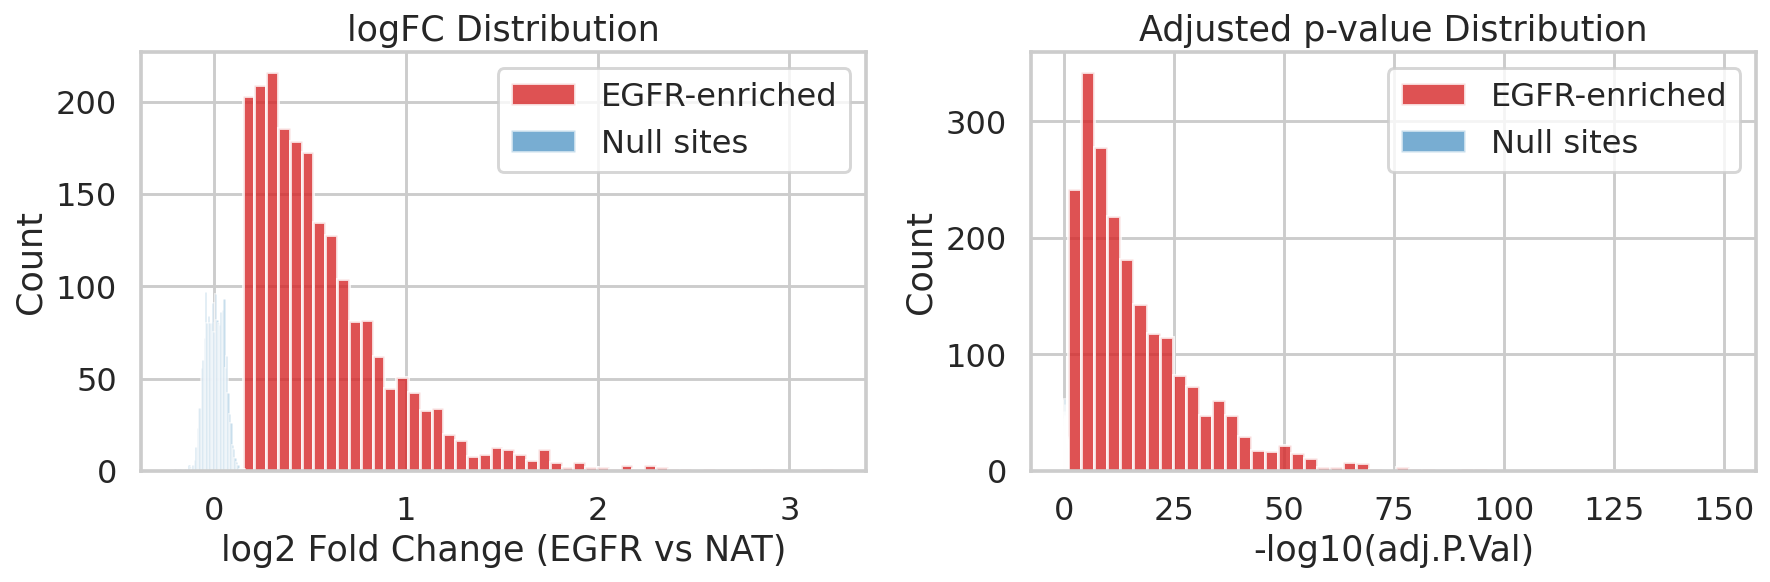

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR_ProtT5/02_logFC_pval_distributions.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(egfr_clean["logFC"], bins=50, color="#d62728", alpha=0.8, label="EGFR-enriched")
axes[0].hist(null_clean["logFC"],  bins=50, color="#1f77b4", alpha=0.6, label="Null sites")
axes[0].set_xlabel("log2 Fold Change (EGFR vs NAT)")
axes[0].set_ylabel("Count")
axes[0].set_title("logFC Distribution")
axes[0].legend()

axes[1].hist(-np.log10(egfr_clean["adj.P.Val"].clip(lower=1e-160)), bins=50, color="#d62728", alpha=0.8, label="EGFR-enriched")
axes[1].hist(-np.log10(null_clean["adj.P.Val"].clip(lower=1e-160)),  bins=50, color="#1f77b4", alpha=0.6, label="Null sites")
axes[1].set_xlabel("-log10(adj.P.Val)")
axes[1].set_ylabel("Count")
axes[1].set_title("Adjusted p-value Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_logFC_pval_distributions.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '02_logFC_pval_distributions.png'}")

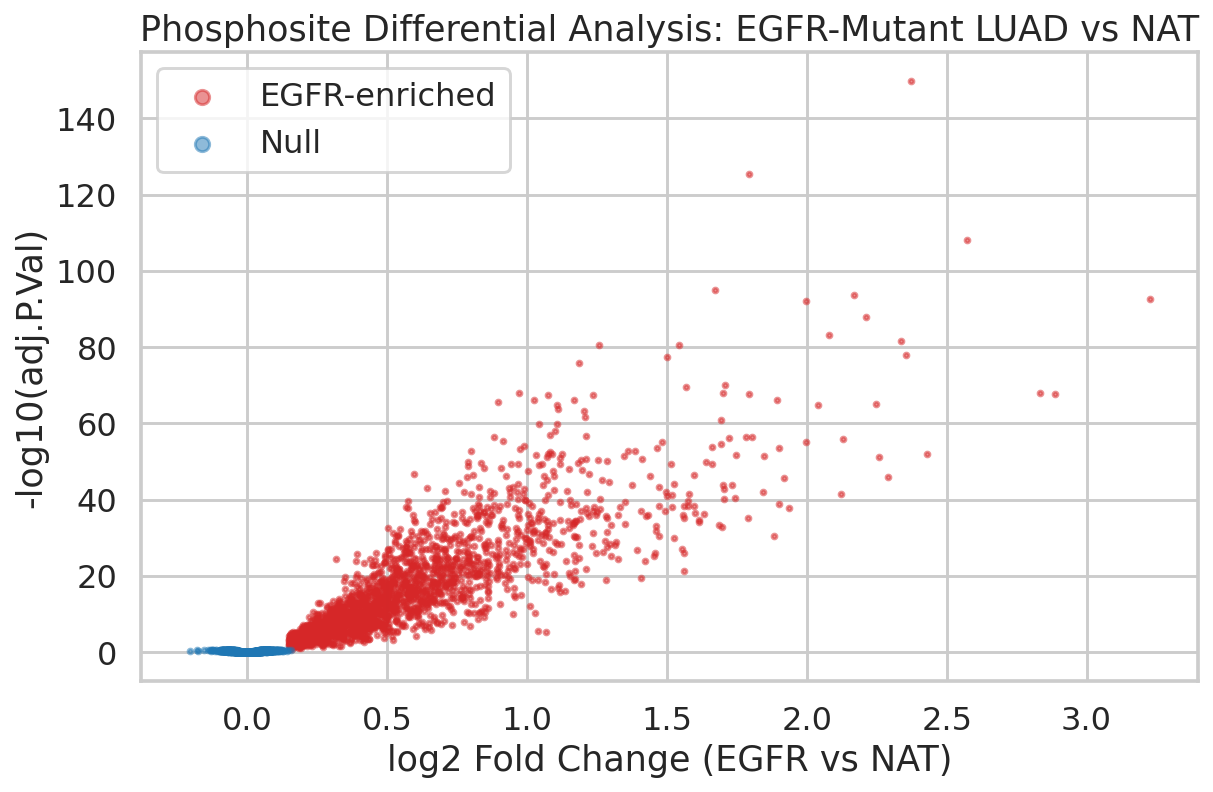

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR_ProtT5/03_scatter_logFC_vs_pval.png


In [7]:
combined_eda = pd.concat([
    egfr_clean.assign(group="EGFR-enriched"),
    null_clean.assign(group="Null")
], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 6))
palette = {"EGFR-enriched": "#d62728", "Null": "#1f77b4"}
for grp, sub in combined_eda.groupby("group"):
    ax.scatter(
        sub["logFC"],
        -np.log10(sub["adj.P.Val"].clip(lower=1e-160)),
        s=6, alpha=0.5, color=palette[grp], label=grp, rasterized=True
    )
ax.set_xlabel("log2 Fold Change (EGFR vs NAT)")
ax.set_ylabel("-log10(adj.P.Val)")
ax.set_title("Phosphosite Differential Analysis: EGFR-Mutant LUAD vs NAT")
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_scatter_logFC_vs_pval.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '03_scatter_logFC_vs_pval.png'}")

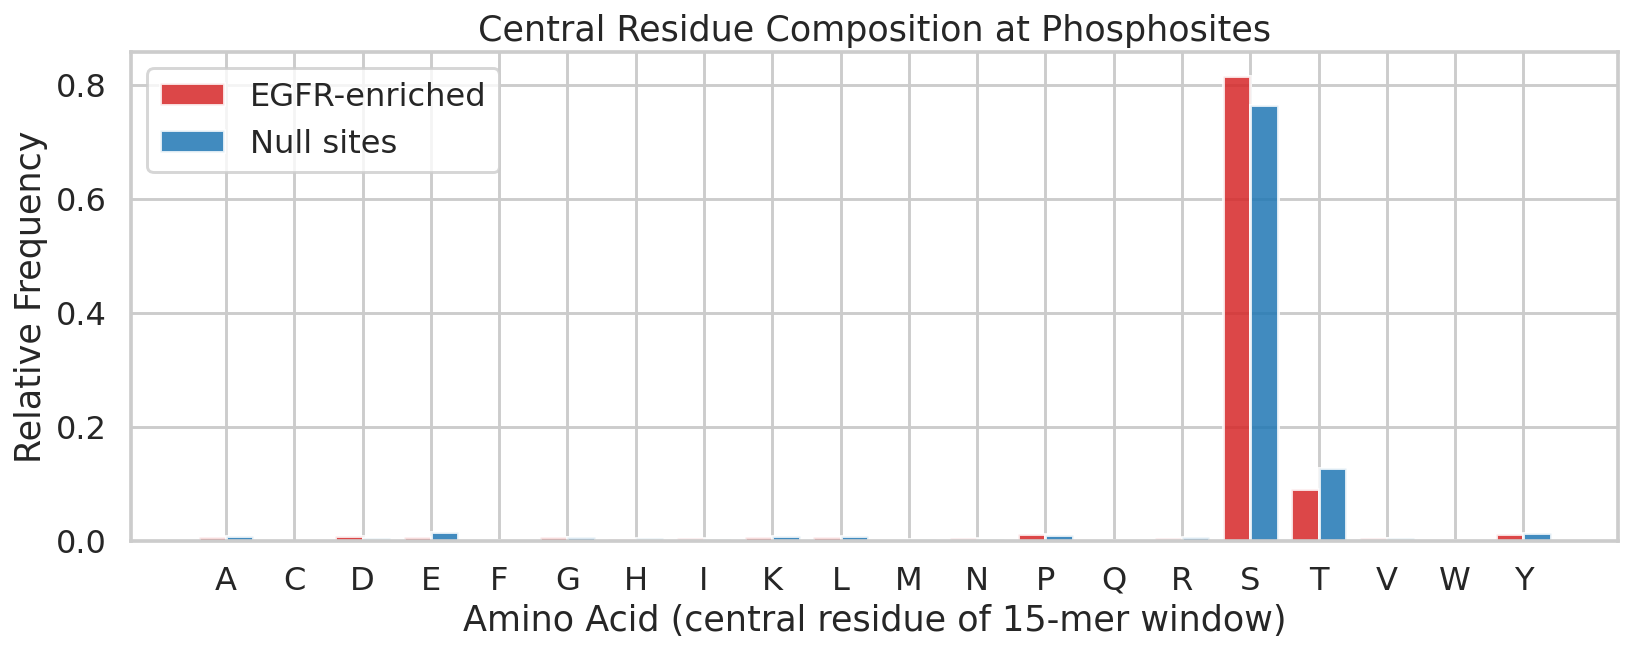

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR_ProtT5/04_central_residue_composition.png


In [8]:
def central_residue(seq):
    if isinstance(seq, str) and len(seq) == 15:
        return seq[7].upper()
    return None

egfr_clean["central_aa"] = egfr_clean["win15_seq"].apply(central_residue)
null_clean["central_aa"]  = null_clean["win15_seq"].apply(central_residue)

aas = sorted(set(egfr_clean["central_aa"].dropna()) | set(null_clean["central_aa"].dropna()))
egfr_freq = egfr_clean["central_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)
null_freq  = null_clean["central_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)

x = np.arange(len(aas))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, egfr_freq.values, width, label="EGFR-enriched", color="#d62728", alpha=0.85)
ax.bar(x + width/2, null_freq.values,  width, label="Null sites",    color="#1f77b4", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(aas)
ax.set_xlabel("Amino Acid (central residue of 15-mer window)")
ax.set_ylabel("Relative Frequency")
ax.set_title("Central Residue Composition at Phosphosites")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "04_central_residue_composition.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '04_central_residue_composition.png'}")

## Cell 5 — ProtT5 Protein Embedding

We use **`Rostlab/prot_t5_xl_uniref50`** (3 B parameters, 1024-dim per-residue representations).  
Full protein sequences are embedded once and cached to `prott5_window_embeddings.npz`.

**Tokenisation note:** ProtT5 requires space-separated amino acids (`"M A K L ..."`).  
T5 adds only EOS at the end (no BOS). After encoding, `hidden[j, :seq_len]` directly gives  
0-based residue embeddings aligned with `win15_start / win15_end`.

> BATCH_SIZE=1 — ProtT5-XL is ~3 B parameters; larger batches will OOM on a single GPU.

In [9]:
PROTT5_MODEL_NAME = "Rostlab/prot_t5_xl_uniref50"
PROTT5_MAX_LEN    = 1024   # total tokens including EOS; sequences truncated to 1023 residues
PROTT5_BATCH_SIZE = 1      # keep at 1 — ProtT5-XL is ~3 B parameters


def sequence_to_id(seq: str) -> str:
    return hashlib.md5(seq.encode()).hexdigest()


def preprocess_prott5(seq: str) -> str:
    """Space-separate amino acids; replace ambiguous residues with X."""
    seq = re.sub(r"[UZOB]", "X", seq.upper())
    return " ".join(list(seq))


def load_prott5_model():
    print(f"Loading {PROTT5_MODEL_NAME} …")
    tokenizer = T5Tokenizer.from_pretrained(PROTT5_MODEL_NAME, do_lower_case=False)
    model = T5EncoderModel.from_pretrained(PROTT5_MODEL_NAME).to(device).eval()
    embed_dim = model.config.d_model
    print(f"ProtT5 model loaded | embed_dim={embed_dim}")
    return model, tokenizer, embed_dim


@torch.no_grad()
def embed_proteins_prott5(df: pd.DataFrame, model, tokenizer) -> dict:
    """
    Embed unique protein sequences with ProtT5.
    Returns {protein_id: (seq_len, 1024) tensor on CPU}.

    Tokenisation:
      - T5 adds only EOS at the end (no BOS).
      - Sequence pre-truncated to PROTT5_MAX_LEN-1 residues so that
        tokenised length (residues + EOS) <= PROTT5_MAX_LEN.
      - hidden[j, :seq_len] gives 0-based residue embeddings that align
        directly with win15_start / win15_end columns.
    """
    emb_dict = {}
    unique_seqs = df["Sequence"].drop_duplicates().tolist()
    max_res = PROTT5_MAX_LEN - 1  # max residues (leave 1 slot for EOS)

    for i in tqdm(range(0, len(unique_seqs), PROTT5_BATCH_SIZE), desc="Embedding proteins (ProtT5)"):
        batch_seqs = unique_seqs[i:i + PROTT5_BATCH_SIZE]
        pids = [sequence_to_id(s) for s in batch_seqs]

        # Pre-truncate then space-separate
        batch_trunc  = [s[:max_res] for s in batch_seqs]
        batch_spaced = [preprocess_prott5(s) for s in batch_trunc]

        tokens = tokenizer(
            batch_spaced,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=PROTT5_MAX_LEN,
        ).to(device)

        out    = model(input_ids=tokens.input_ids, attention_mask=tokens.attention_mask)
        hidden = out.last_hidden_state   # (B, padded_L, 1024)

        for j, (pid, seq_trunc) in enumerate(zip(pids, batch_trunc)):
            seq_len = len(seq_trunc)           # number of residues (no EOS)
            emb_dict[pid] = hidden[j, :seq_len].cpu()   # (seq_len, 1024)

    return emb_dict


print("ProtT5 embedding functions defined.")

ProtT5 embedding functions defined.


In [10]:
# ── Load or compute ProtT5 protein embeddings ────────────────────────────────
all_proteins = pd.concat(
    [egfr_clean[["Sequence"]], null_clean[["Sequence"]]]
).drop_duplicates()
print(f"Unique proteins to embed: {len(all_proteins)}")

if EMBED_CACHE.exists():
    print(f"Loading cached embeddings from {EMBED_CACHE} …")
    cache_data = np.load(EMBED_CACHE, allow_pickle=True)
    protein_embeddings = cache_data["embeddings"].item()
    print(f"Loaded {len(protein_embeddings)} embeddings from cache.")
else:
    print("Cache not found — running ProtT5 embedding (this will take a while) …")
    t0 = time.time()
    prott5_model, prott5_tokenizer, EMBED_DIM = load_prott5_model()
    protein_embeddings = embed_proteins_prott5(all_proteins, prott5_model, prott5_tokenizer)
    elapsed = time.time() - t0
    print(f"Embedding complete in {elapsed:.1f}s | {len(protein_embeddings)} proteins")
    np.savez(EMBED_CACHE, embeddings=protein_embeddings)
    print(f"Embeddings cached to {EMBED_CACHE}")
    del prott5_model, prott5_tokenizer
    if device.type == "cuda":
        torch.cuda.empty_cache()

EMBED_DIM = next(iter(protein_embeddings.values())).shape[1]
print(f"Embedding dim: {EMBED_DIM}")

Unique proteins to embed: 2304
Cache not found — running ProtT5 embedding (this will take a while) …
Loading Rostlab/prot_t5_xl_uniref50 …


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


ProtT5 model loaded | embed_dim=1024


Embedding proteins (ProtT5): 100%|██████████| 2304/2304 [05:42<00:00,  6.73it/s]


Embedding complete in 351.6s | 2304 proteins
Embeddings cached to /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/prott5_window_embeddings.npz
Embedding dim: 1024


## Cell 6 — 15-Residue Window Extraction

In [11]:
def build_window_dataset(df: pd.DataFrame, label: int, protein_embeddings: dict):
    """
    Slice the 15-residue context window around each phosphosite.
    win15_start / win15_end are 0-based amino-acid positions.
    ProtT5 hidden[j, :seq_len] gives 0-based residue embeddings
    that align directly with these columns.

    Returns:
        X    : (N, 15, EMBED_DIM) float32
        y    : (N,) int
        kept : original DataFrame indices that were kept
    """
    X, y, kept = [], [], []
    skipped_missing_emb = 0
    skipped_boundary    = 0

    for idx, row in df.iterrows():
        if pd.isna(row["win15_start"]) or pd.isna(row["win15_end"]):
            continue

        pid = sequence_to_id(row["Sequence"])
        if pid not in protein_embeddings:
            skipped_missing_emb += 1
            continue

        emb = protein_embeddings[pid]   # (L, 1024)
        s   = int(row["win15_start"])
        e   = int(row["win15_end"])

        if e - s + 1 != 15:
            continue

        if e >= emb.shape[0]:
            skipped_boundary += 1
            continue

        X.append(emb[s:e + 1].numpy())   # (15, 1024)
        y.append(label)
        kept.append(idx)

    print(f"[label={label}] Extracted {len(X)} windows "
          f"| skipped: {skipped_missing_emb} (no emb), {skipped_boundary} (boundary)")
    return np.stack(X), np.array(y), kept


X_pos, y_pos, idx_pos = build_window_dataset(egfr_clean, 1, protein_embeddings)
X_neg, y_neg, idx_neg = build_window_dataset(null_clean,  0, protein_embeddings)

X = np.concatenate([X_pos, X_neg], axis=0).astype(np.float32)  # (N, 15, 1024)
y = np.concatenate([y_pos, y_neg], axis=0)                     # (N,)

print(f"\nCombined dataset : X={X.shape}, y={y.shape}")
print(f"Class balance    : {(y==1).sum()} positive / {(y==0).sum()} negative")

[label=1] Extracted 1796 windows | skipped: 0 (no emb), 306 (boundary)
[label=0] Extracted 1451 windows | skipped: 0 (no emb), 314 (boundary)

Combined dataset : X=(3247, 15, 1024), y=(3247,)
Class balance    : 1796 positive / 1451 negative


## Cell 7 — Train / Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print("Train set:")
print(f"  X_train : {X_train.shape}")
print(f"  Positive: {(y_train==1).sum()}  Negative: {(y_train==0).sum()}")
print(f"  Positive fraction: {(y_train==1).mean():.4f}")
print()
print("Test set:")
print(f"  X_test  : {X_test.shape}")
print(f"  Positive: {(y_test==1).sum()}  Negative: {(y_test==0).sum()}")
print(f"  Positive fraction: {(y_test==1).mean():.4f}")
print(f"  PR-AUC random baseline ≈ {(y_test==1).mean():.4f}")

Train set:
  X_train : (2597, 15, 1024)
  Positive: 1436  Negative: 1161
  Positive fraction: 0.5529

Test set:
  X_test  : (650, 15, 1024)
  Positive: 360  Negative: 290
  Positive fraction: 0.5538
  PR-AUC random baseline ≈ 0.5538


## Cell 8 — Model Definitions

Same four architectures as the Ankh / ESM2 pipelines, adapted for 1024-dim input:

| Model | Description |
|---|---|
| **MaxPool MLP** | Max-pools 15 residues → MLP |
| **AttentionPool MLP** | Learned attention weights over 15 residues → MLP |
| **CenterOnly MLP** | Uses only the phosphosite residue embedding (index 7) → MLP |
| **Hybrid** | Concatenates center residue + attention-pooled context → MLP |

In [13]:
class MaxPool(nn.Module):
    def forward(self, x):
        return x.max(dim=1).values


class AttentionPool(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        scores  = self.attn(x).squeeze(-1)
        weights = F.softmax(scores, dim=1)
        return (x * weights.unsqueeze(-1)).sum(dim=1)


class PhosphoMLP(nn.Module):
    def __init__(self, pool: nn.Module, dim: int):
        super().__init__()
        self.pool = pool
        self.mlp = nn.Sequential(
            nn.Linear(dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.mlp(self.pool(x)).squeeze(-1)


class CenterOnlyMLP(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x[:, 7, :]).squeeze(-1)


class HybridMLP(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.attn_pool = AttentionPool(dim)
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 128),     nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        center  = x[:, 7, :]
        context = self.attn_pool(x)
        return self.classifier(torch.cat([center, context], dim=1)).squeeze(-1)


print("All model classes defined.")

All model classes defined.


## Cell 9 — Training Loop

In [14]:
def train_and_eval(
    model: nn.Module,
    X_tr: np.ndarray, y_tr: np.ndarray,
    X_va: np.ndarray, y_va: np.ndarray,
    epochs: int = 20,
    lr: float = 1e-3,
    batch_size: int = 64,
) -> tuple:
    model = model.to(device)

    pos_weight = torch.tensor(
        (y_tr == 0).sum() / (y_tr == 1).sum(), dtype=torch.float32
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    loader = DataLoader(
        TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.float32),
        ),
        batch_size=batch_size,
        shuffle=True,
    )

    val_X = torch.tensor(X_va, dtype=torch.float32).to(device)

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(val_X)).cpu().numpy()

    return probs, roc_auc_score(y_va, probs), average_precision_score(y_va, probs)


print("Training helper defined.")

Training helper defined.


In [15]:
D = EMBED_DIM   # 1024 for ProtT5-XL

models_to_train = {
    "MaxPool MLP":     PhosphoMLP(MaxPool(),       dim=D),
    "AttnPool MLP":    PhosphoMLP(AttentionPool(D), dim=D),
    "CenterOnly MLP":  CenterOnlyMLP(dim=D),
    "Hybrid (C+Attn)": HybridMLP(dim=D),
}

results = {}

for name, model in models_to_train.items():
    print(f"Training: {name} …", end=" ", flush=True)
    t0 = time.time()
    probs, roc, pr = train_and_eval(
        model, X_train, y_train, X_test, y_test, epochs=20
    )
    elapsed = time.time() - t0
    results[name] = {"probs": probs, "roc_auc": roc, "pr_auc": pr}
    print(f"AUROC={roc:.4f}  AUPRC={pr:.4f}  [{elapsed:.1f}s]")

print("\nAll models trained.")

Training: MaxPool MLP … AUROC=0.5385  AUPRC=0.6120  [1.8s]
Training: AttnPool MLP … AUROC=0.5967  AUPRC=0.6361  [1.9s]
Training: CenterOnly MLP … AUROC=0.5654  AUPRC=0.5971  [1.7s]
Training: Hybrid (C+Attn) … AUROC=0.5832  AUPRC=0.6065  [2.0s]

All models trained.


## Cell 10 — ROC & Precision-Recall Curves

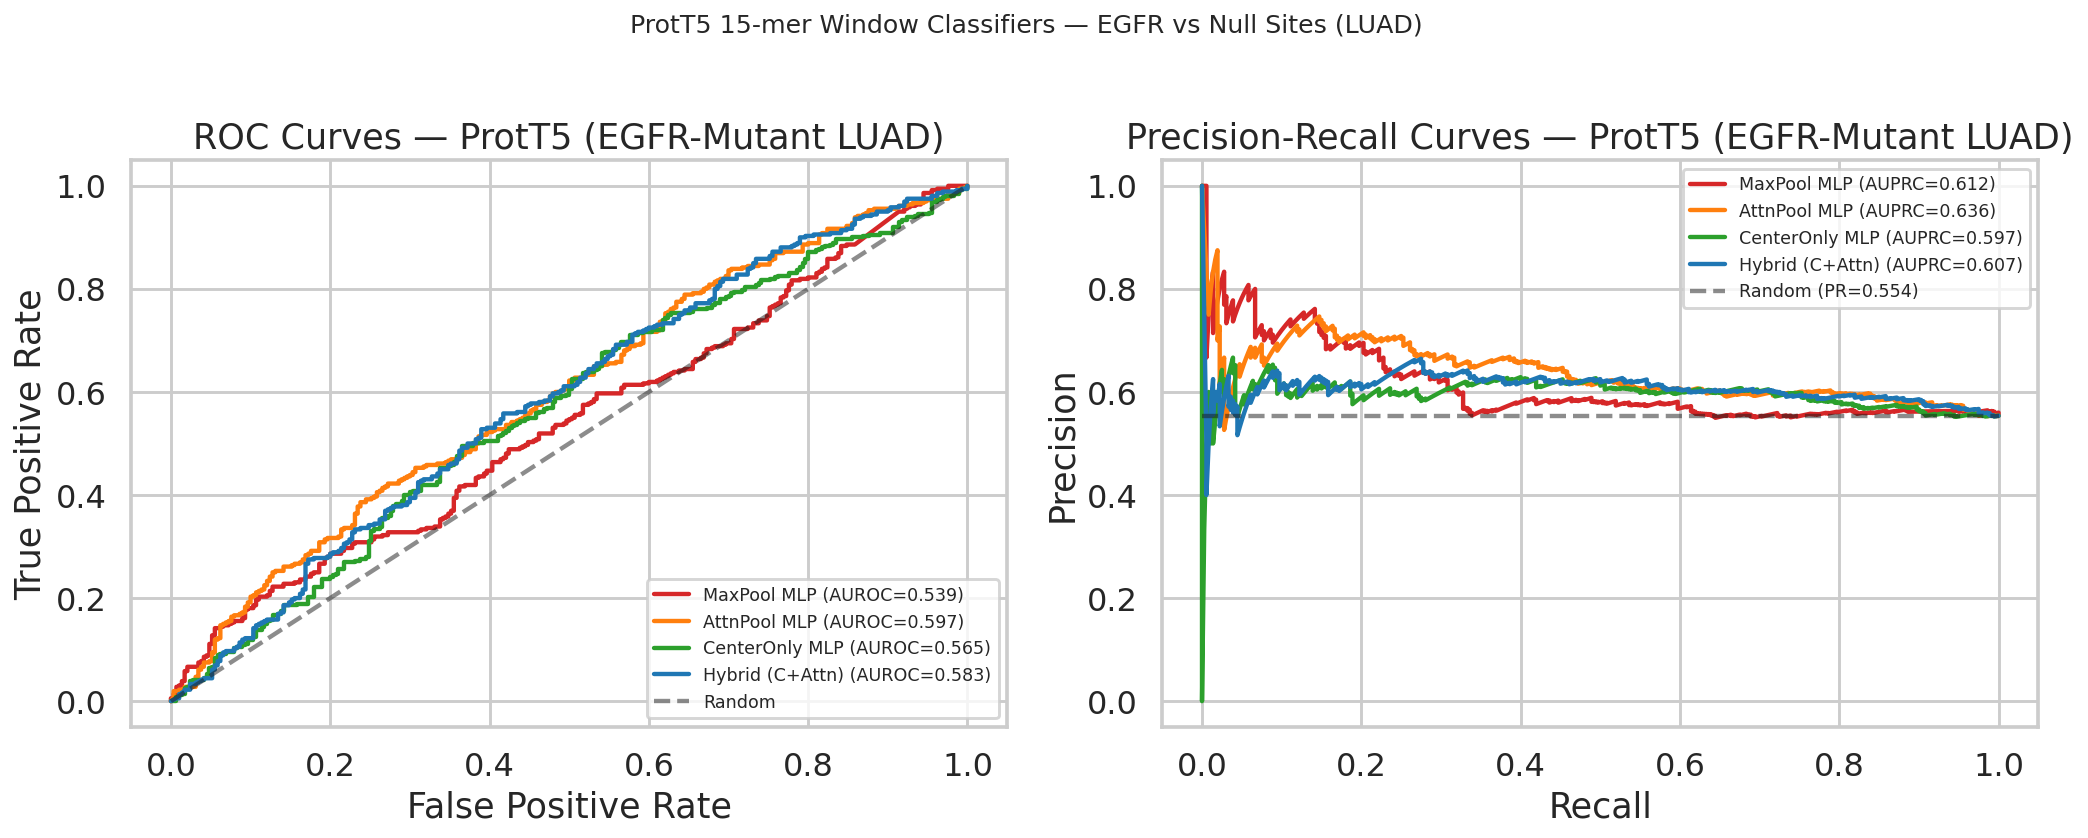

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR_ProtT5/05_roc_pr_curves.png


In [16]:
PALETTE = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
baseline_pr = (y_test == 1).mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for (name, res), color in zip(results.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, res["probs"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUROC={res['roc_auc']:.3f})", color=color)

    prec, rec, _ = precision_recall_curve(y_test, res["probs"])
    axes[1].plot(rec, prec, label=f"{name} (AUPRC={res['pr_auc']:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — ProtT5 (EGFR-Mutant LUAD)")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].hlines(baseline_pr, 0, 1, linestyles="--", colors="k", alpha=0.5,
               label=f"Random (PR={baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — ProtT5 (EGFR-Mutant LUAD)")
axes[1].legend(loc="upper right", fontsize=9)

plt.suptitle("ProtT5 15-mer Window Classifiers — EGFR vs Null Sites (LUAD)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "05_roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '05_roc_pr_curves.png'}")

## Cell 11 — Detailed Metrics & Confusion Matrices

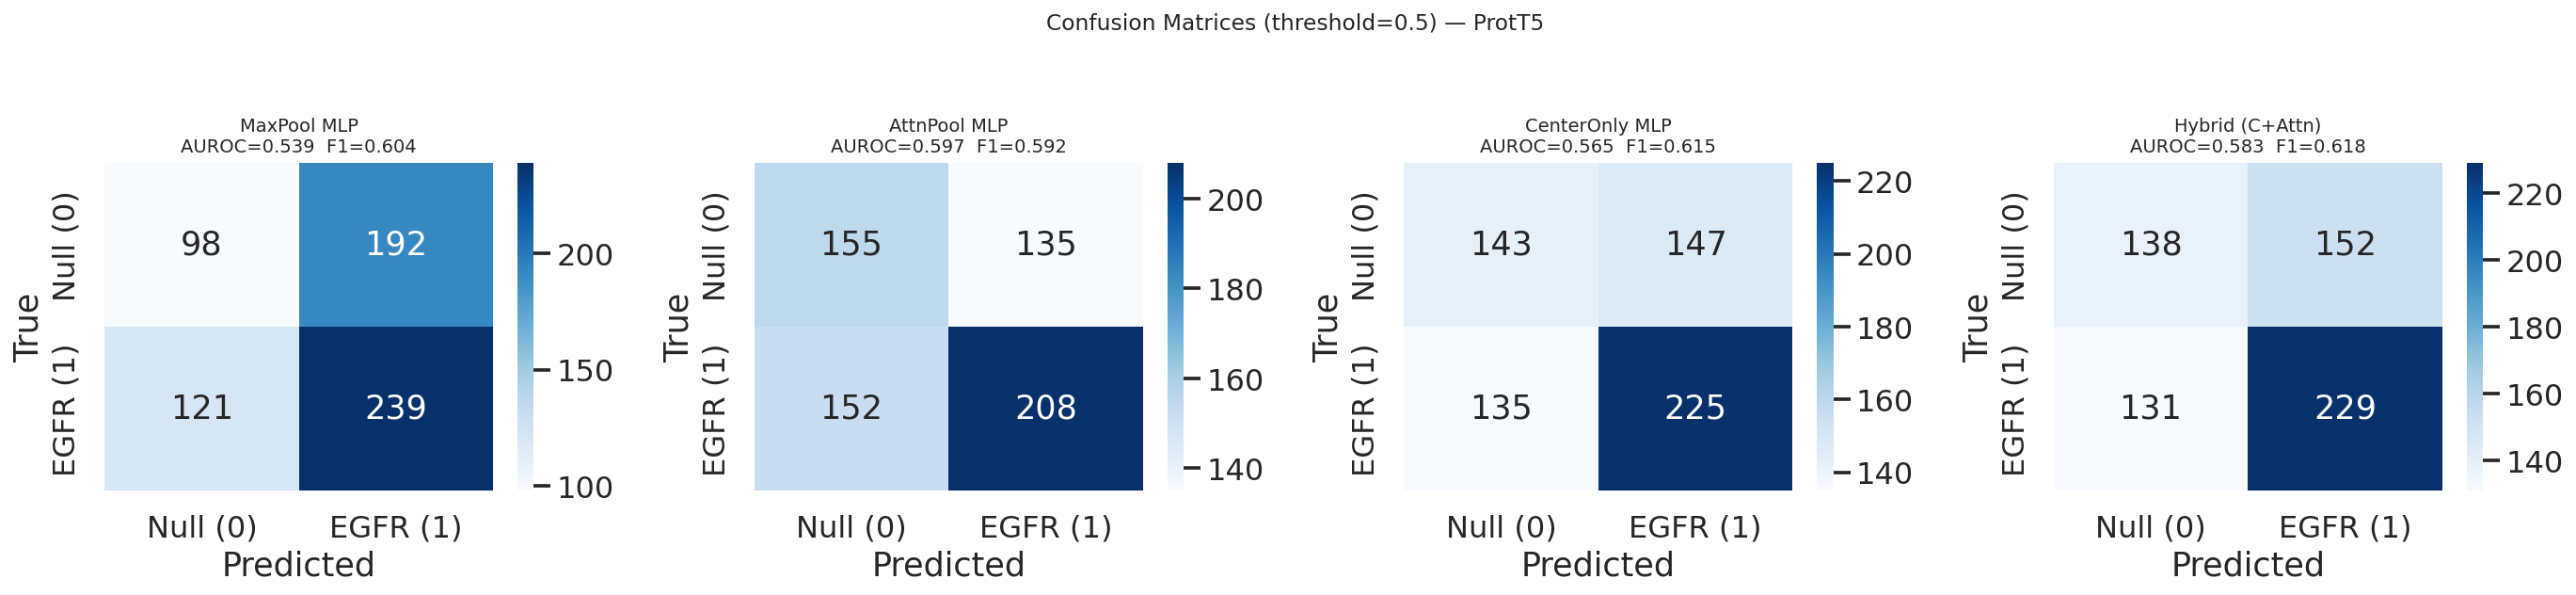

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR_ProtT5/06_confusion_matrices.png


In [17]:
THRESHOLD = 0.5
metrics_rows = []

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    preds = (res["probs"] >= THRESHOLD).astype(int)
    prec  = precision_score(y_test, preds, zero_division=0)
    rec   = recall_score(y_test, preds, zero_division=0)
    f1    = f1_score(y_test, preds, zero_division=0)

    metrics_rows.append({
        "Model":     name,
        "AUROC":     round(res["roc_auc"], 4),
        "AUPRC":     round(res["pr_auc"], 4),
        "Precision": round(prec, 4),
        "Recall":    round(rec, 4),
        "F1":        round(f1, 4),
    })

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Null (0)", "EGFR (1)"],
        yticklabels=["Null (0)", "EGFR (1)"],
    )
    ax.set_title(f"{name}\nAUROC={res['roc_auc']:.3f}  F1={f1:.3f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices (threshold=0.5) — ProtT5", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "06_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '06_confusion_matrices.png'}")

In [18]:
metrics_df = pd.DataFrame(metrics_rows).sort_values("AUROC", ascending=False).reset_index(drop=True)
print("=== Model Performance Summary ===")
display(metrics_df)

metrics_df.to_csv(RESULTS_DIR / "07_model_metrics_summary.csv", index=False)
print(f"\nSaved: {RESULTS_DIR / '07_model_metrics_summary.csv'}")

=== Model Performance Summary ===


,Model,AUROC,AUPRC,Precision,Recall,F1
0,AttnPool MLP,0.5967,0.6361,0.6064,0.5778,0.5917
1,Hybrid (C+Attn),0.5832,0.6065,0.6010,0.6361,0.6181
2,CenterOnly MLP,0.5654,0.5971,0.6048,0.6250,0.6148
3,MaxPool MLP,0.5385,0.6120,0.5545,0.6639,0.6043



Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR_ProtT5/07_model_metrics_summary.csv


## Cell 12 — Embedding Visualisation (PCA + t-SNE)

In [19]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X_mean_pool = X.mean(axis=1)   # (N, 1024)

pca = PCA(n_components=50, random_state=SEED)
X_pca50 = pca.fit_transform(X_mean_pool)
print(f"PCA 50-component variance explained: {pca.explained_variance_ratio_.sum():.2%}")

X_pca2 = X_pca50[:, :2]

print("Running t-SNE … (may take ~1 min)")
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)
print("t-SNE done.")

PCA 50-component variance explained: 69.21%
Running t-SNE … (may take ~1 min)
t-SNE done.


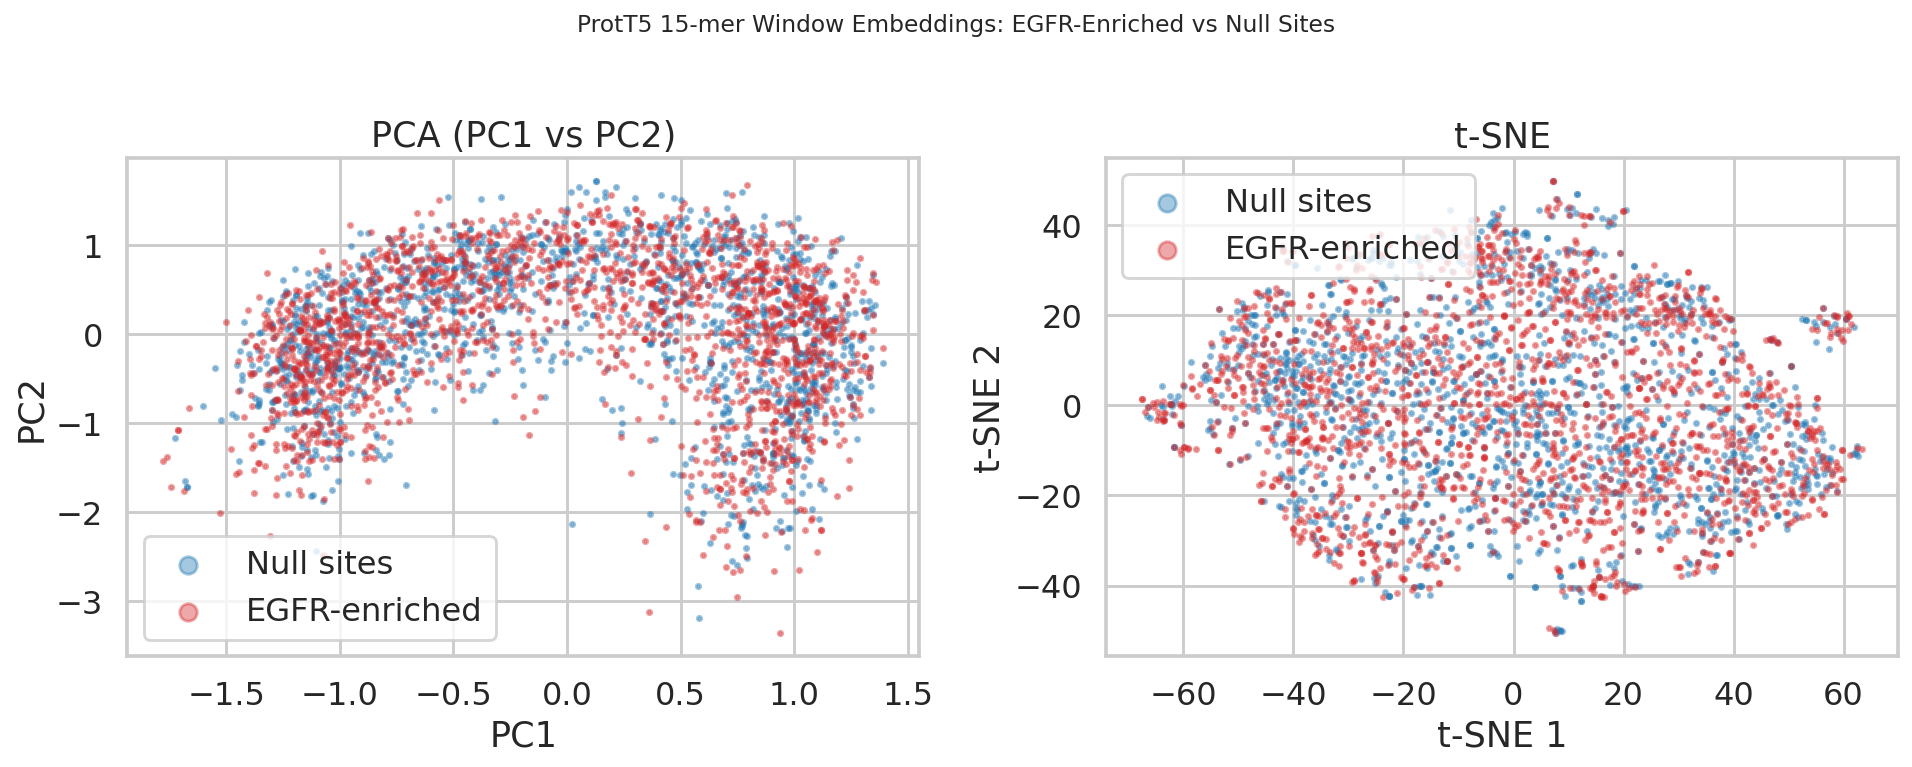

Saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR_ProtT5/08_pca_tsne.png


In [20]:
label_colors = {1: "#d62728", 0: "#1f77b4"}
label_names  = {1: "EGFR-enriched", 0: "Null sites"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for label in [0, 1]:
    mask = y == label
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    s=5, alpha=0.4, color=label_colors[label],
                    label=label_names[label], rasterized=True)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    s=5, alpha=0.4, color=label_colors[label],
                    label=label_names[label], rasterized=True)

axes[0].set_title("PCA (PC1 vs PC2)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=4)

axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(markerscale=4)

plt.suptitle("ProtT5 15-mer Window Embeddings: EGFR-Enriched vs Null Sites",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "08_pca_tsne.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / '08_pca_tsne.png'}")

## Cell 13 — HTML Summary Report

In [21]:
import base64


def img_to_b64(path: Path) -> str:
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{data}" style="max-width:100%;"/>'


plot_files   = sorted(RESULTS_DIR.glob("*.png"))
metrics_html = metrics_df.to_html(index=False, border=1,
                                   classes="metrics", justify="center")

html_parts = [
    """<!DOCTYPE html>
<html><head>
<meta charset='utf-8'/>
<title>ProtT5 Phospho EGFR LUAD — Analysis Report</title>
<style>
  body { font-family: Arial, sans-serif; max-width: 1100px; margin: auto; padding: 20px; }
  h1   { color: #1a3c34; }
  h2   { color: #2c3e50; border-bottom: 2px solid #ccc; padding-bottom: 4px; }
  table.metrics { border-collapse: collapse; width: 100%; }
  table.metrics th, table.metrics td { border: 1px solid #aaa; padding: 8px 14px; text-align: center; }
  table.metrics th { background-color: #1a3c34; color: white; }
  .plot-grid { display: flex; flex-wrap: wrap; gap: 16px; }
  .plot-grid figure { margin: 0; text-align: center; }
</style>
</head><body>
<h1>ProtT5 Differential Phosphorylation Classifier</h1>
<h2>Dataset: EGFR-Mutant LUAD vs Normal Adjacent Tissue (NAT)</h2>
<p><b>EGFR-enriched sites:</b> 2 189 &nbsp;|&nbsp; <b>Null sites:</b> 1 844</p>
<p><b>Model:</b> ProtT5-XL-UniRef50 (1024-dim) 15-residue context window around phosphosite</p>
<hr/>
<h2>Model Performance Summary</h2>
""",
    metrics_html,
    "<hr/>\n<h2>Plots</h2>\n<div class='plot-grid'>\n",
]

for p in plot_files:
    html_parts.append(f"<figure>{img_to_b64(p)}<figcaption>{p.name}</figcaption></figure>\n")

html_parts.append("</div></body></html>")

report_path = RESULTS_DIR / "report_phospho_egfr_luad_prott5.html"
report_path.write_text("".join(html_parts), encoding="utf-8")
print(f"HTML report saved: {report_path}")

HTML report saved: /home/saishyam/Protein_dynamics/Dynamic_properties/LUAD_diff_Phospho_EGFR_NAT/EGFR_UP_vs_Null_sites/Claude_Agent_Phospho_EGFR_NAT_LUAD/results_phospho_EGFR_ProtT5/report_phospho_egfr_luad_prott5.html


## Cell 14 — Final Summary

In [22]:
print("=" * 60)
print("FINAL RESULTS SUMMARY — ProtT5")
print("=" * 60)
print(f"Dataset  : EGFR-mutant LUAD differential phosphoproteomics")
print(f"Positive : EGFR-enriched sites  ({(y==1).sum()} samples)")
print(f"Negative : Null sites           ({(y==0).sum()} samples)")
print(f"Embedder : ProtT5-XL-UniRef50, 1024 dim, 15-residue window")
print(f"Split    : 80% train / 20% test, stratified")
print()

random_auroc = 0.5
random_prauc = (y_test == 1).mean()
print("Random baselines (test set):")
print(f"  AUROC  (random) = {random_auroc:.4f}")
print(f"  PR-AUC (random) = {random_prauc:.4f}  "
      f"[= positive class fraction = {(y_test==1).sum()}/{len(y_test)}]")
print()

print("Model Results vs Random Baseline:")
print(f"{'Model':<20} {'AUROC':>7} {'vs_rand':>9} {'AUPRC':>7} {'vs_rand':>9} {'F1':>7}")
print("-" * 65)
for _, row in metrics_df.iterrows():
    auroc_gain = row["AUROC"] - random_auroc
    prauc_gain = row["AUPRC"] - random_prauc
    print(f"{row['Model']:<20} {row['AUROC']:>7.4f} {auroc_gain:>+9.4f} "
          f"{row['AUPRC']:>7.4f} {prauc_gain:>+9.4f} {row['F1']:>7.4f}")
print()

best = metrics_df.iloc[0]
print(f"Best model : {best['Model']}")
print(f"  AUROC  = {best['AUROC']:.4f}  (random = {random_auroc:.4f}, "
      f"gain = {best['AUROC'] - random_auroc:+.4f})")
print(f"  PR-AUC = {best['AUPRC']:.4f}  (random = {random_prauc:.4f}, "
      f"gain = {best['AUPRC'] - random_prauc:+.4f})")
print(f"  F1     = {best['F1']:.4f}")
print()
print("All outputs saved to:", RESULTS_DIR.resolve())
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"  {f.name}")

FINAL RESULTS SUMMARY — ProtT5
Dataset  : EGFR-mutant LUAD differential phosphoproteomics
Positive : EGFR-enriched sites  (1796 samples)
Negative : Null sites           (1451 samples)
Embedder : ProtT5-XL-UniRef50, 1024 dim, 15-residue window
Split    : 80% train / 20% test, stratified

Random baselines (test set):
  AUROC  (random) = 0.5000
  PR-AUC (random) = 0.5538  [= positive class fraction = 360/650]

Model Results vs Random Baseline:
Model                  AUROC   vs_rand   AUPRC   vs_rand      F1
-----------------------------------------------------------------
AttnPool MLP          0.5967   +0.0967  0.6361   +0.0823  0.5917
Hybrid (C+Attn)       0.5832   +0.0832  0.6065   +0.0527  0.6181
CenterOnly MLP        0.5654   +0.0654  0.5971   +0.0433  0.6148
MaxPool MLP           0.5385   +0.0385  0.6120   +0.0582  0.6043

Best model : AttnPool MLP
  AUROC  = 0.5967  (random = 0.5000, gain = +0.0967)
  PR-AUC = 0.6361  (random = 0.5538, gain = +0.0823)
  F1     = 0.5917

All outputs 